In [1]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

import numpy as np
import matplotlib.pyplot as plt

In [52]:
#Create a random variable "x" and then create a polynomial equation using those value
X = 4* np.random.rand(200, 1) - 3
y = 0.75 * X**2 + 0.9 * X + 2 - np.random.rand(200,1) # added some noise into the dataset
## y = 1.5X^2 + 1.3X + 2

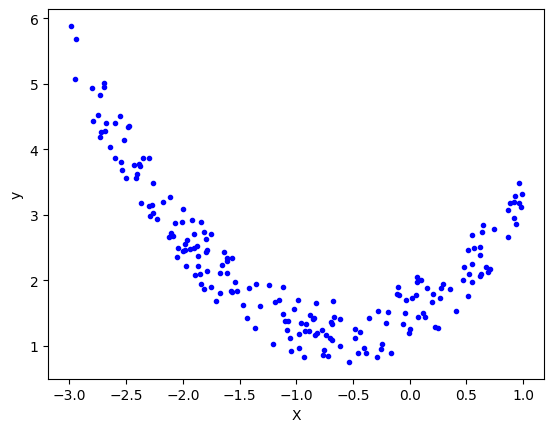

In [53]:
# plt.figure(figsize=(6,4))
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [77]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [78]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [79]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.3254739229453093

In [81]:
lr.coef_, lr.intercept_

(array([[-0.45189548]]), array([1.80608438]))

Text(0, 0.5, 'y')

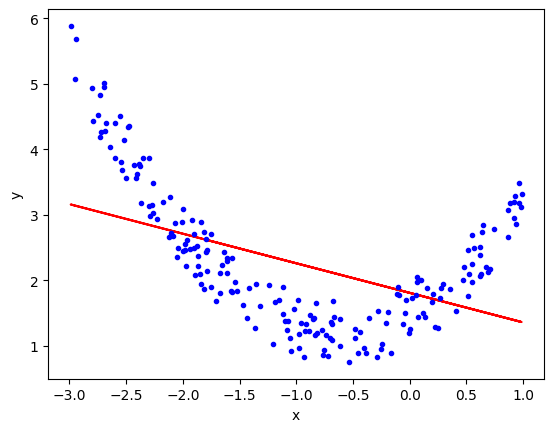

In [80]:
plt.plot(X_train, lr.predict(X_train), color = 'r')
plt.plot(X,y, "b.")
plt.xlabel("x")
plt.ylabel("y")

In [82]:
# Applying Polynomial Linear Regression
# and assumeing degree 2

poly = PolynomialFeatures(degree=2, include_bias=True) # include_bias=True to add a constant term i.e intercept
#if false then there will no incercept and calculate only for x**2 and x
X_train_transform = poly.fit_transform(X_train)
X_test_transform = poly.fit_transform(X_test)

#We do not need to transform y_train and y_test

In [83]:
print(X_train[0])
print(X_train_transform[0])

[0.96801097]
[1.         0.96801097 0.93704525]


In [84]:
lr = LinearRegression()
lr.fit(X_train_transform,y_train)

LinearRegression()

In [85]:
y_pred = lr.predict(X_test_transform)
r2_score(y_test, y_pred)

0.9401078586890041

In [86]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.96151416 0.77858055]]
[1.49685819]


In [87]:
## y = 1.5X^2 + 1.3X + 2

In [88]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

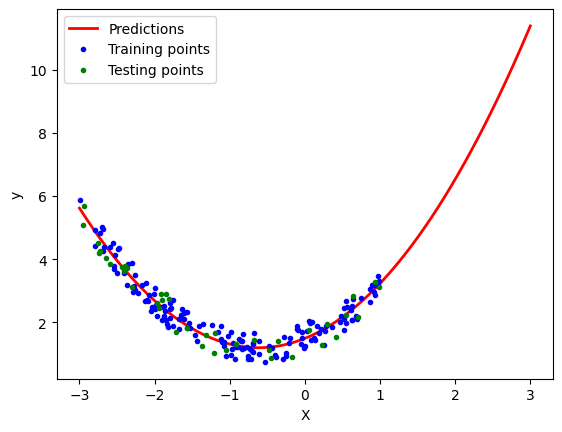

In [89]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [90]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

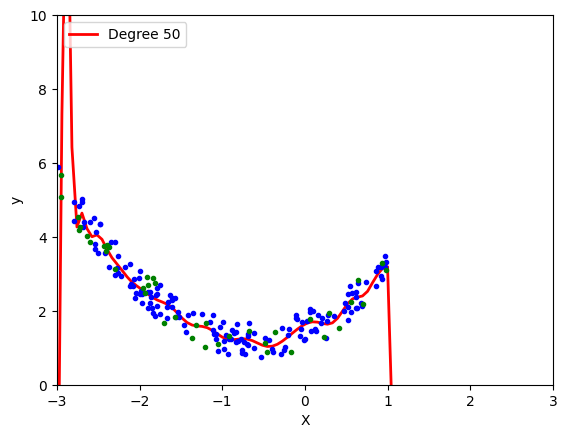

In [91]:
polynomial_regression(50)

c:\Users\RAJU SINGH\.virtualenvs\Gradient_Descent_Intro-Vko8eK12\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


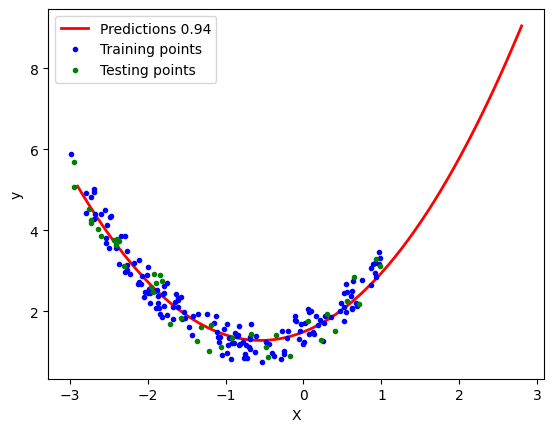

In [76]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [92]:
y_pred = sgd.predict(X_test_trans)
r2_score(y_test, y_pred)

0.9386308752753103

In [93]:
sgd.coef_, sgd.intercept_

(array([0.74590832, 0.76383613, 0.69143631]), array([0.74638931]))

In [94]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

# Load diabetes dataset
diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 2]  # Using only one feature for simplicity
y = diabetes.target

# Define the polynomial degrees to test
degree_range = [1, 2, 3, 4, 5]

# Grid Search Cross-Validation
best_degree = None
best_score = float("inf")

for degree in degree_range:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
    avg_score = -np.mean(scores)  # Convert to positive MSE
    
    print(f"Degree {degree} - Avg MSE: {avg_score:.2f}")
    
    if avg_score < best_score:
        best_score = avg_score
        best_degree = degree

print(f"\nBest Polynomial Degree (Grid Search CV): {best_degree}")

# Fit the best model
best_model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
best_model.fit(X, y)

y_pred = best_model.predict(X)

# Compute AIC & BIC
n = len(y)
k = best_degree + 1  # Number of parameters (degree + intercept)
MSE = mean_squared_error(y, y_pred)
AIC = n * np.log(MSE) + 2 * k
BIC = n * np.log(MSE) + k * np.log(n)

print(f"AIC: {AIC:.2f}")
print(f"BIC: {BIC:.2f}")


ModuleNotFoundError: No module named 'statsmodels'